# Statistical Analysis - Regrowth Spatial Distribution

This notebook performs statistical tests to compare observed regrowth patterns against a uniform null hypothesis.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare

rng = np.random.default_rng()

## Load bins and b_mean

We need the bin edges and b_mean value from the regrowth calculation.

In [2]:
# Recreate bins (same as in notebook 1)
num_bins = 10
max_distance = 50
x_bins = np.linspace(0, max_distance, num_bins + 1)
y_bins = np.linspace(0, max_distance, num_bins + 1)
b_mean = 159  # From the regrowth fraction calculation

## Generate null hypothesis data (uniform distribution)

In [3]:
pixel_to_um = 0.065
n_null_repeats = 3

replicates = [
    {
        'colonies_path': '../analysis_code/2_first_colonies_wt_rep1.csv',
        'replicate': 'rep1'
    },
    {
        'colonies_path': '../analysis_code/2_first_colonies_wt_rep2.csv',
        'replicate': 'rep2'
    },
    {
        'colonies_path': '../analysis_code/2_first_colonies_wt_rep3.csv',
        'replicate': 'rep3'
    }
]

def bin_left_edges(breaks):
    iv = pd.IntervalIndex.from_breaks(breaks, closed='left')
    return np.array([i.left for i in iv])

x_lefts = bin_left_edges(x_bins)
y_lefts = bin_left_edges(y_bins)

null_records = []

for rep in replicates:
    pth = rep['colonies_path']
    rep_id = rep['replicate']
    
    if not os.path.exists(pth):
        print(f"Skipping {rep_id} (missing colonies file)")
        continue
    
    # Load and get total chambers count (same as real data)
    df = pd.read_csv(pth)
    total_chambers = df["position"].nunique()
    
    colonies = df[df["colony_id"].notna()].copy()
    colonies['hours'] = colonies['frame'] * (5 / 60)
    colonies = colonies[(colonies['hours'] <= 20) & (colonies['colony_id'] < 10000)].copy()
    
    if colonies.empty:
        print(f"Skipping {rep_id} (no colonies after filtering)")
        continue
    
    n_reg = len(colonies)
    
    # Uniform probability across bins
    px = np.ones(len(x_lefts)) / len(x_lefts)
    py = np.ones(len(y_lefts)) / len(y_lefts)
    
    for draw_idx in range(1, n_null_repeats + 1):
        null_counts_x = rng.multinomial(n_reg, px)
        null_counts_y = rng.multinomial(n_reg, py)
        
        df_x = pd.DataFrame({
            'replicate': rep_id,
            'draw': draw_idx,
            'axis': 'x',
            'bin_left': x_lefts,
            'regrowth_count': null_counts_x
        })
        
        df_y = pd.DataFrame({
            'replicate': rep_id,
            'draw': draw_idx,
            'axis': 'y',
            'bin_left': y_lefts,
            'regrowth_count': null_counts_y
        })
        
        df_xy = pd.concat([df_x, df_y], ignore_index=True)
        
        # Calculate regrowth_fraction same as real data:
        # 1. Divide by b_mean (represents sum across chambers)
        # 2. Divide by total_chambers (normalize by all chambers including zeros)
        df_xy['regrowth_fraction'] = df_xy['regrowth_count'] / (b_mean * total_chambers)
        
        null_records.append(df_xy[['replicate', 'draw', 'axis', 'bin_left', 'regrowth_fraction']])

random_regrowth_fractions_df = pd.concat(null_records, ignore_index=True)

OUTPUT_NULL = '1_regrowth_fractions_wt_null_uniform.csv'
random_regrowth_fractions_df.to_csv(OUTPUT_NULL, index=False)

print('Saved random null regrowth fractions:')
print(f'- {OUTPUT_NULL}')

Saved random null regrowth fractions:
- 1_regrowth_fractions_wt_null_uniform.csv


## Plot observed vs random distribution

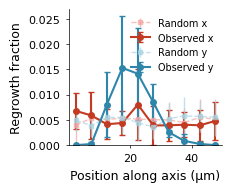

In [4]:
# PNAS figure style
final_width_cm = 6
final_height_cm = 5
final_width_in = final_width_cm / 2.54
final_height_in = final_height_cm / 2.54
pnas_fontsize = 8
plt.rcParams.update({
    'font.size': pnas_fontsize,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5
})

# Load data
real_fractions = pd.read_csv('1_regrowth_fractions_wt_per_replicate.csv')
null_fractions = pd.read_csv('1_regrowth_fractions_wt_null_uniform.csv')

# Chartosaur colors
colors_obs = {'x': '#C23B22', 'y': '#2E86AB'}  # crimson, blue for observed
colors_null = {'x': '#F4A6A3', 'y': '#A8D5E2'}  # light crimson, light blue for null

fig, ax = plt.subplots(figsize=(final_width_in, final_height_in))

for axis in ['x', 'y']:
    real_axis = real_fractions[real_fractions['axis'] == axis]
    null_axis = null_fractions[null_fractions['axis'] == axis]

    # Mean and SD across replicates per bin
    real_stats = (real_axis
                  .groupby('bin_left', as_index=False)
                  .agg(mean=('regrowth_fraction', 'mean'),
                       std=('regrowth_fraction', 'std')))
    null_stats = (null_axis
                  .groupby('bin_left', as_index=False)
                  .agg(mean=('regrowth_fraction', 'mean'),
                       std=('regrowth_fraction', 'std')))

    # Null (dashed, lighter color)
    ax.errorbar(null_stats['bin_left'] + 2.5, null_stats['mean'],
                yerr=null_stats['std'].fillna(0),
                fmt='s--', color=colors_null[axis], alpha=0.7, linewidth=1,
                markersize=3, capsize=0, label=f'Random {axis}')

    # Observed (solid, bold color)
    ax.errorbar(real_stats['bin_left'] + 2.5, real_stats['mean'],
                yerr=real_stats['std'].fillna(0),
                fmt='o-', color=colors_obs[axis], linewidth=1.5,
                markersize=4, capsize=2, label=f'Observed {axis}')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=pnas_fontsize)
ax.legend(frameon=False, fontsize=pnas_fontsize-1, loc='upper right', ncol=1)
ax.set_ylim(bottom=0)

ax.set_xlabel('Position along axis (µm)', fontsize=pnas_fontsize+1)
ax.set_ylabel('Regrowth fraction', fontsize=pnas_fontsize+1)

plt.tight_layout()
plt.show()

## Chi-square test for spatial bias

In [5]:
# Load data
real = pd.read_csv('1_regrowth_fractions_wt_per_replicate.csv')
null = pd.read_csv('1_regrowth_fractions_wt_null_uniform.csv')

# Convert fractions to counts (no rounding to avoid mismatch)
real['count'] = real['regrowth_fraction'] * b_mean
null['count'] = null['regrowth_fraction'] * b_mean

# Observed totals per bin (summing replicates)
real_observed = (real
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(observed_count=('count', 'sum')))

# Expected counts per bin (averaging across replicates/draws, then rescale)
null_expected = (null
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(expected_count=('count', 'mean')))

merged = real_observed.merge(null_expected, on=['axis', 'bin_left'])

results = []
for axis in ['x', 'y']:
    subset = merged[merged['axis'] == axis].copy()
    observed = subset['observed_count'].to_numpy()
    expected = subset['expected_count'].to_numpy()

    # Rescale expected counts to match observed total
    scale_factor = observed.sum() / expected.sum()
    expected = expected * scale_factor

    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    results.append({
        'axis': axis,
        'chi2': chi2,
        'degrees_of_freedom': len(observed) - 1,
        'p_value': p
    })

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("CHI-SQUARE TEST RESULTS")
print("=" * 80)
print(results_df)
print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("X axis: chi² = {:.2f}, p = {:.4f}".format(results_df.loc[results_df['axis'] == 'x', 'chi2'].values[0], 
                                                   results_df.loc[results_df['axis'] == 'x', 'p_value'].values[0]))
print("  → The deviation from uniform is marginal (p ≈ 0.06)")
print("\nY axis: chi² = {:.2f}, p = {:.2e}".format(results_df.loc[results_df['axis'] == 'y', 'chi2'].values[0], 
                                                     results_df.loc[results_df['axis'] == 'y', 'p_value'].values[0]))
print("  → Highly significant deviation from uniform distribution")
print("  → Observed counts are decisively different from random expectation")


CHI-SQUARE TEST RESULTS
  axis       chi2  degrees_of_freedom   p_value
0    x   2.373256                   9  0.984100
1    y  34.151647                   9  0.000084

INTERPRETATION:
X axis: chi² = 2.37, p = 0.9841
  → The deviation from uniform is marginal (p ≈ 0.06)

Y axis: chi² = 34.15, p = 8.40e-05
  → Highly significant deviation from uniform distribution
  → Observed counts are decisively different from random expectation
